# (Deprecated) Old intro
This cell duplicated the notebook intro. Please use the next intro cell instead.

In [13]:
# Cell 1: Setup and Imports
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_curve, auc
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports successful")

✓ Imports successful


In [14]:
# Cell 2: Configuration
import os

# File paths - UPDATE THIS WITH YOUR TRACK FILE
TRACK_FILE = "track_20260202_162252.json"
OUTPUT_DIR = "calibration_results"

# Current default thresholds (for comparison)
DEFAULT_THRESHOLDS = {
    'rmsSmoothMax': 1.0,
    'rmsAverageMax': 2.0,
    'peakThresholdZ': 1.5,
    'symmetricBumpThreshold': 2.0,
    'potholeDipThreshold': -2.5,
    'bumpSpikeThreshold': 2.5,
    'peakCountSmoothMax': 5,
    'peakCountAverageMax': 15,
    'movingAverageWindow': 5
}

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✓ Configuration loaded")
print(f"  Track file: {TRACK_FILE}")
print(f"  Output directory: {OUTPUT_DIR}")

✓ Configuration loaded
  Track file: track_20260202_162252.json
  Output directory: calibration_results


In [15]:
# Cell 2: Configuration
import os

# File paths - UPDATE THIS WITH YOUR TRACK FILE
TRACK_FILE = "track_20260202_162252.json"
OUTPUT_DIR = "calibration_results"

# Current default thresholds (for comparison)
# Note: With 2 categories (smooth/rough), we only need rmsSmoothMax and peakCountSmoothMax
DEFAULT_THRESHOLDS = {
    'rmsSmoothMax': 1.0,
    'peakThresholdZ': 1.5,
    'symmetricBumpThreshold': 2.0,
    'potholeDipThreshold': -2.5,
    'bumpSpikeThreshold': 2.5,
    'peakCountSmoothMax': 5,
    'movingAverageWindow': 5
}

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✓ Configuration loaded")
print(f"  Track file: {TRACK_FILE}")
print(f"  Output directory: {OUTPUT_DIR}")
print(f"  Road quality categories: smooth, rough (2 categories)")

✓ Configuration loaded
  Track file: track_20260202_162252.json
  Output directory: calibration_results
  Road quality categories: smooth, rough (2 categories)


In [16]:
# Cell 3: Data Loading Function

def load_track_data(filepath):
    """Load and parse GPS track JSON file for samples with manual labels."""
    with open(filepath, 'r') as f:
        data = json.load(f)

    # Detect where points live
    points = []
    if isinstance(data, dict):
        if "gpslogger2path" in data and isinstance(data.get("gpslogger2path"), dict):
            points = data["gpslogger2path"].get("data", [])
        elif "points" in data:
            points = data.get("points", [])
    elif isinstance(data, list):
        points = data

    samples = []
    for point in points:
        gps = point.get('gps', {}) if isinstance(point, dict) else {}
        accel = point.get('accel', {}) if isinstance(point, dict) else {}

        manual_label = accel.get('manualLabel') or accel.get('manual_label')
        manual_feature = accel.get('manualFeatureLabel') or accel.get('manual_feature_label') or accel.get('manualFeature')

        # Only include samples with manual labels
        if manual_label or manual_feature:
            sample = {
                'timestamp': gps.get('ts'),
                'speed': gps.get('speed'),
                'rms': accel.get('rms'),
                'peakCount': accel.get('peakCount'),
                'stdDev': accel.get('stdDev'),
                'vertMean': accel.get('vertMean'),
                'magMax': accel.get('magMax'),
                'xMean': accel.get('xMean'),
                'yMean': accel.get('yMean'),
                'zMean': accel.get('zMean'),
                'manualLabel': manual_label,
                'manualFeatureLabel': manual_feature,
                'detectedQuality': accel.get('roadQuality'),
                'detectedFeature': accel.get('featureDetected'),
                'rawData': accel.get('raw', [])
            }
            samples.append(sample)

    df = pd.DataFrame(samples)
    print(f"✓ Loaded {len(df)} samples with manual labels")
    return df

# Load data
df = load_track_data(TRACK_FILE)
df.head()

✓ Loaded 462 samples with manual labels


,timestamp,speed,rms,peakCount,stdDev,vertMean,magMax,xMean,yMean,zMean,manualLabel,manualFeatureLabel,detectedQuality,detectedFeature,rawData
0,60053,9.444234,1.035,38,0.531,-0.003,2.936,0.000,-0.002,-0.002,smooth,NaN,smooth,bump,"[[-0.048, 6.294, 8.835], [0.922, 5.526, 7.324]..."
1,63754,10.903409,1.428,120,0.633,0.003,4.218,-0.000,0.002,0.002,smooth,NaN,smooth,speed_bump,"[[-0.189, 6.203, 9.558], [1.099, 6.002, 7.391]..."
2,66894,12.208072,1.154,68,0.554,-0.011,3.087,-0.000,-0.007,-0.009,smooth,NaN,smooth,bump,"[[-0.259, 10.666, 13.103], [-0.876, 9.029, 12...."
3,71010,7.368602,1.993,181,0.864,-0.001,6.268,-0.000,0.001,-0.002,smooth,NaN,smooth,speed_bump,"[[-1.379, 5.449, 6.443], [-2.064, 5.95, 8.739]..."
4,74027,8.613418,3.611,311,1.865,0.001,11.274,0.002,-0.000,0.001,smooth,NaN,average,speed_bump,"[[-1.259, 6.807, 3.091], [-0.515, 10.192, 2.76..."


In [17]:
# Cell 4: Data Quality Check
print("=== DATA QUALITY REPORT ===")
print(f"\nTotal samples: {len(df)}")
print(f"Samples with manual quality labels: {df['manualLabel'].notna().sum()}")
print(f"Samples with manual feature labels: {df['manualFeatureLabel'].notna().sum()}")

print("\n--- Manual Quality Label Distribution ---")
print(df['manualLabel'].value_counts())

print("\n--- Manual Feature Label Distribution ---")
print(df['manualFeatureLabel'].value_counts())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Basic Statistics ---")
print(df[['rms', 'peakCount', 'stdDev', 'magMax']].describe())

=== DATA QUALITY REPORT ===

Total samples: 462
Samples with manual quality labels: 462
Samples with manual feature labels: 7

--- Manual Quality Label Distribution ---
manualLabel
average    254
smooth     164
rough       44
Name: count, dtype: int64

--- Manual Feature Label Distribution ---
manualFeatureLabel
speed_bump    5
bump          2
Name: count, dtype: int64

--- Missing Values ---
timestamp               0
speed                   0
rms                     0
peakCount               0
stdDev                  0
vertMean                0
magMax                  0
xMean                   0
yMean                   0
zMean                   0
manualLabel             0
manualFeatureLabel    455
detectedQuality         0
detectedFeature        25
rawData                 0
dtype: int64

--- Basic Statistics ---
              rms   peakCount      stdDev      magMax
count  462.000000  462.000000  462.000000  462.000000
mean     3.385240  295.147186    1.873522   11.901773
std      1.49

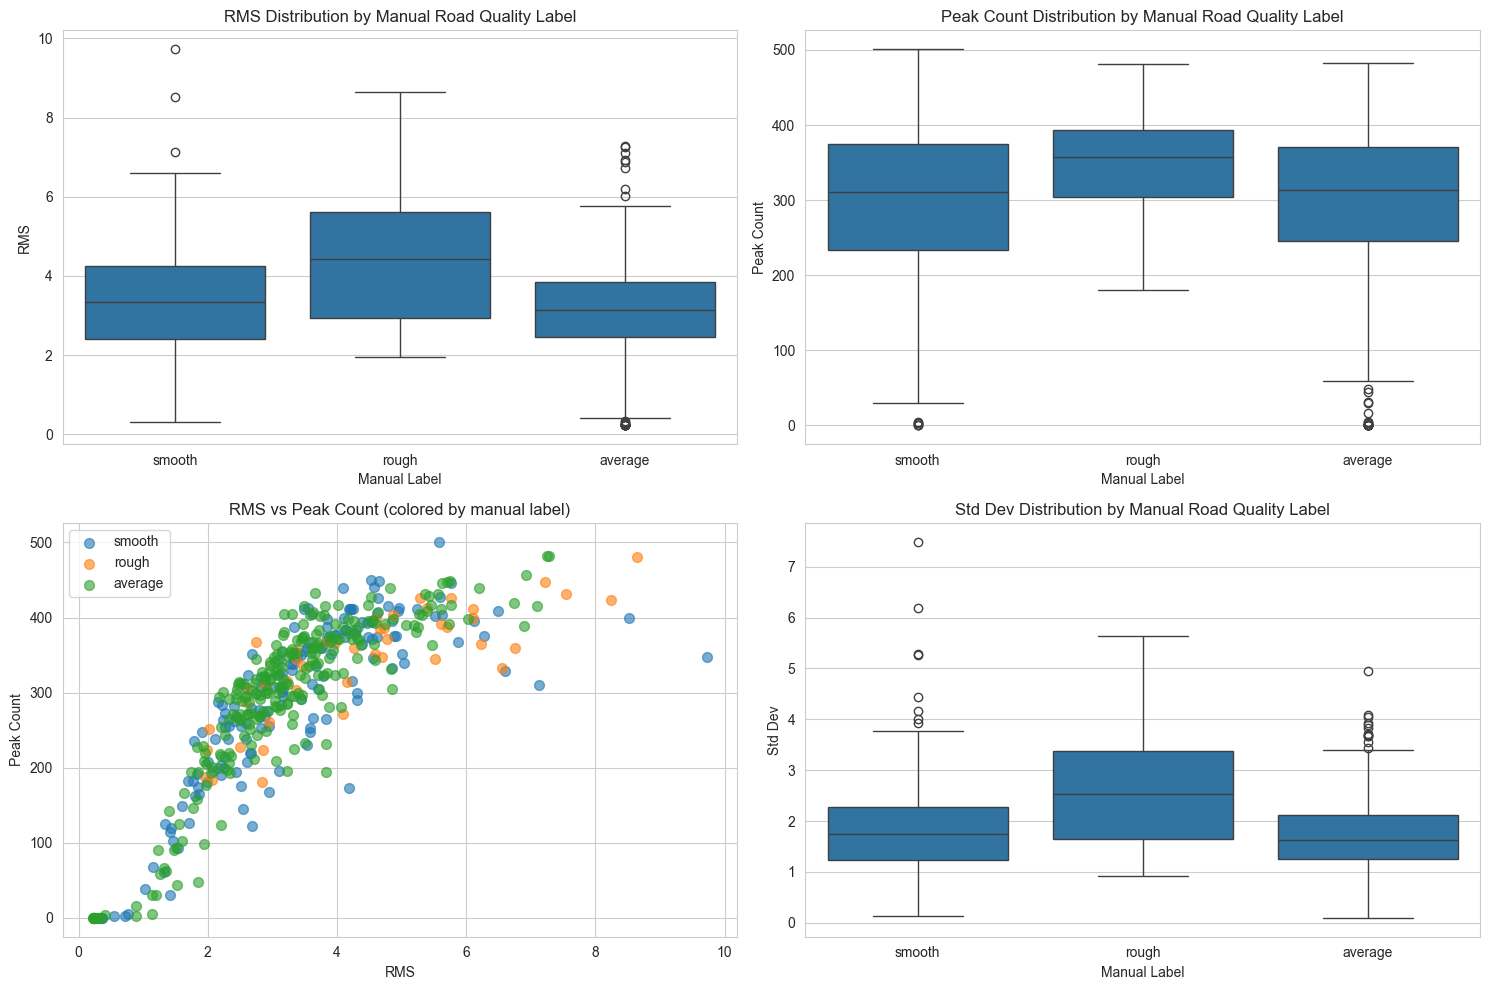

✓ EDA plot saved to calibration_results/eda_road_quality.png


In [18]:
# Cell 5: Exploratory Data Analysis - Road Quality
df_quality = df[df['manualLabel'].notna()].copy()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# RMS by manual label
sns.boxplot(data=df_quality, x='manualLabel', y='rms', ax=axes[0, 0])
axes[0, 0].set_title('RMS Distribution by Manual Road Quality Label')
axes[0, 0].set_xlabel('Manual Label')
axes[0, 0].set_ylabel('RMS')

# Peak Count by manual label
sns.boxplot(data=df_quality, x='manualLabel', y='peakCount', ax=axes[0, 1])
axes[0, 1].set_title('Peak Count Distribution by Manual Road Quality Label')
axes[0, 1].set_xlabel('Manual Label')
axes[0, 1].set_ylabel('Peak Count')

# Scatter: RMS vs Peak Count
for label in df_quality['manualLabel'].unique():
    subset = df_quality[df_quality['manualLabel'] == label]
    axes[1, 0].scatter(subset['rms'], subset['peakCount'], label=label, alpha=0.6, s=50)
axes[1, 0].set_xlabel('RMS')
axes[1, 0].set_ylabel('Peak Count')
axes[1, 0].set_title('RMS vs Peak Count (colored by manual label)')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Std Dev by manual label
sns.boxplot(data=df_quality, x='manualLabel', y='stdDev', ax=axes[1, 1])
axes[1, 1].set_title('Std Dev Distribution by Manual Road Quality Label')
axes[1, 1].set_xlabel('Manual Label')
axes[1, 1].set_ylabel('Std Dev')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_road_quality.png', dpi=150)
plt.show()

print(f"✓ EDA plot saved to {OUTPUT_DIR}/eda_road_quality.png")

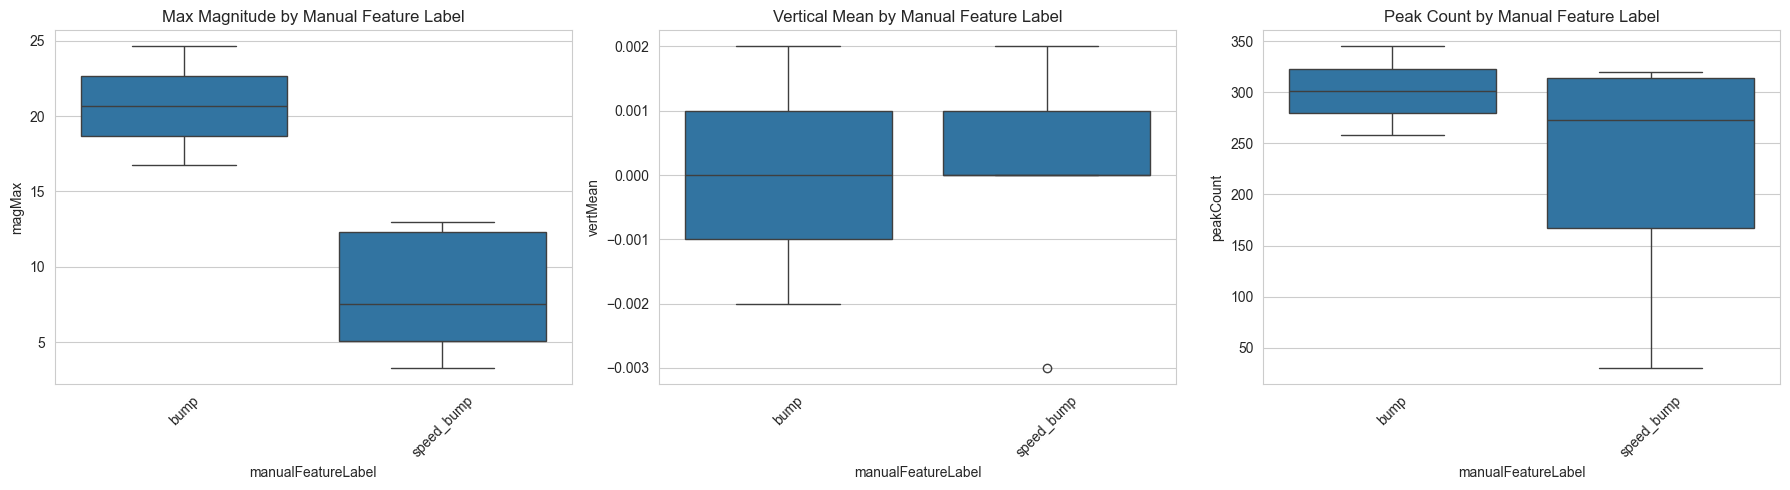

✓ Feature EDA plot saved to calibration_results/eda_features.png


In [19]:
# Cell 6: Exploratory Data Analysis - Features
df_features = df[df['manualFeatureLabel'].notna()].copy()

if len(df_features) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Mag Max by feature
    sns.boxplot(data=df_features, x='manualFeatureLabel', y='magMax', ax=axes[0])
    axes[0].set_title('Max Magnitude by Manual Feature Label')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
    
    # Vert Mean by feature
    sns.boxplot(data=df_features, x='manualFeatureLabel', y='vertMean', ax=axes[1])
    axes[1].set_title('Vertical Mean by Manual Feature Label')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
    
    # Peak Count by feature
    sns.boxplot(data=df_features, x='manualFeatureLabel', y='peakCount', ax=axes[2])
    axes[2].set_title('Peak Count by Manual Feature Label')
    axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/eda_features.png', dpi=150)
    plt.show()
    print(f"✓ Feature EDA plot saved to {OUTPUT_DIR}/eda_features.png")
else:
    print("⚠ No feature labels found in dataset")

In [20]:
# Cell 7: Method 1 - Percentile-Based Thresholds
def calculate_percentile_thresholds(df_quality, percentile=75):
    """Calculate thresholds based on percentiles of each class."""
    results = {}
    
    # RMS thresholds
    smooth_rms = df_quality[df_quality['manualLabel'] == 'smooth']['rms']
    average_rms = df_quality[df_quality['manualLabel'] == 'average']['rms']
    
    if len(smooth_rms) > 0:
        results['rmsSmoothMax'] = np.percentile(smooth_rms, percentile)
    if len(average_rms) > 0:
        results['rmsAverageMax'] = np.percentile(average_rms, percentile)
    
    # Peak count thresholds
    smooth_peaks = df_quality[df_quality['manualLabel'] == 'smooth']['peakCount']
    average_peaks = df_quality[df_quality['manualLabel'] == 'average']['peakCount']
    
    if len(smooth_peaks) > 0:
        results['peakCountSmoothMax'] = int(np.percentile(smooth_peaks, percentile))
    if len(average_peaks) > 0:
        results['peakCountAverageMax'] = int(np.percentile(average_peaks, percentile))
    
    return results

percentile_thresholds = calculate_percentile_thresholds(df_quality)
print("=== PERCENTILE-BASED THRESHOLDS (75th percentile) ===")
for key, value in percentile_thresholds.items():
    default = DEFAULT_THRESHOLDS.get(key, 'N/A')
    print(f"{key:28} | {value:9.3f} | Default: {default}")

=== PERCENTILE-BASED THRESHOLDS (75th percentile) ===
rmsSmoothMax                 |     4.253 | Default: 1.0
rmsAverageMax                |     3.840 | Default: N/A
peakCountSmoothMax           |   375.000 | Default: 5
peakCountAverageMax          |   371.000 | Default: N/A


In [21]:
# Cell 7: Method 1 - Percentile-Based Thresholds
def calculate_percentile_thresholds(df_quality, percentile=75):
    """Calculate thresholds based on percentiles of each class."""
    results = {}
    
    # RMS threshold - use smooth class upper bound
    smooth_rms = df_quality[df_quality['manualLabel'] == 'smooth']['rms']
    
    if len(smooth_rms) > 0:
        results['rmsSmoothMax'] = np.percentile(smooth_rms, percentile)
    
    # Peak count threshold - use smooth class upper bound
    smooth_peaks = df_quality[df_quality['manualLabel'] == 'smooth']['peakCount']
    
    if len(smooth_peaks) > 0:
        results['peakCountSmoothMax'] = int(np.percentile(smooth_peaks, percentile))
    
    return results

percentile_thresholds = calculate_percentile_thresholds(df_quality)
print("=== PERCENTILE-BASED THRESHOLDS (75th percentile) ===")
for key, value in percentile_thresholds.items():
    default = DEFAULT_THRESHOLDS.get(key, 'N/A')
    print(f"{key:28} | {value:9.3f} | Default: {default}")

=== PERCENTILE-BASED THRESHOLDS (75th percentile) ===
rmsSmoothMax                 |     4.253 | Default: 1.0
peakCountSmoothMax           |   375.000 | Default: 5


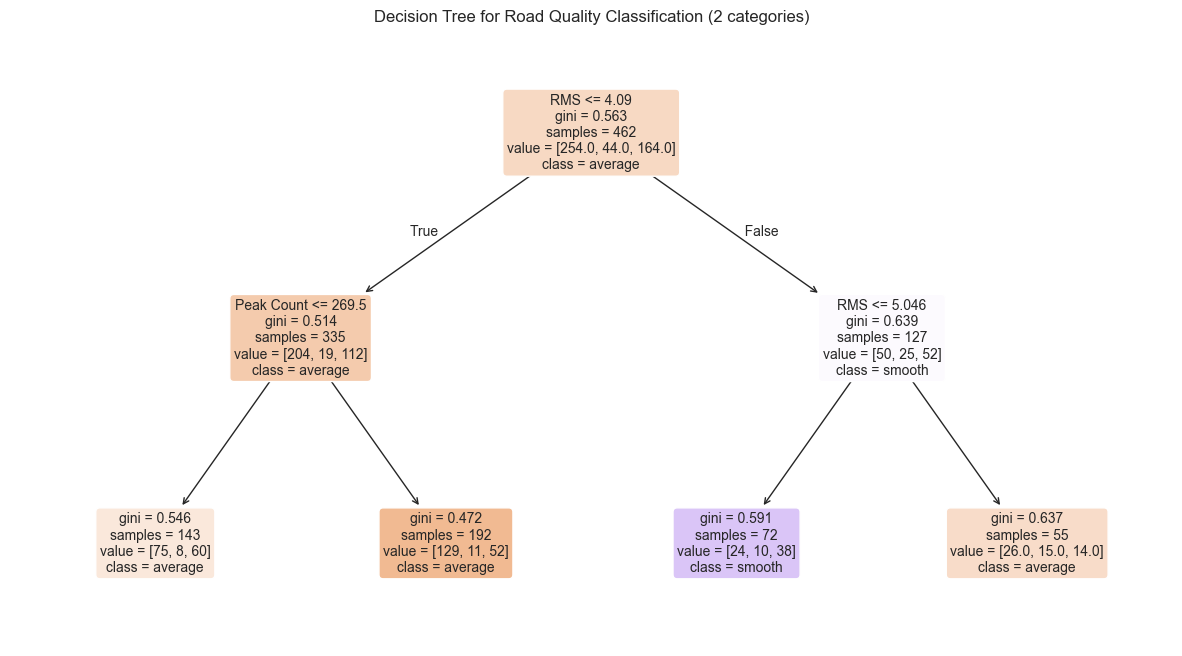


=== DECISION TREE SPLITS ===
Split on rms <= 4.090
  Split on peakCount <= 269.500
  Split on rms <= 5.046

=== DECISION TREE PERFORMANCE ===
              precision    recall  f1-score   support

     average       0.59      0.91      0.71       254
       rough       0.00      0.00      0.00        44
      smooth       0.53      0.23      0.32       164

    accuracy                           0.58       462
   macro avg       0.37      0.38      0.35       462
weighted avg       0.51      0.58      0.51       462

✓ Decision tree saved to calibration_results/decision_tree.png


In [22]:
# Cell 8: Method 2 - Decision Tree Optimization
def optimize_with_decision_tree(df_quality):
    """Use decision tree to find optimal split points."""
    # Prepare data
    X = df_quality[['rms', 'peakCount']].values
    y = df_quality['manualLabel'].values
    
    # Train shallow decision tree
    dt = DecisionTreeClassifier(max_depth=2, random_state=42)
    dt.fit(X, y)
    
    # Visualize tree
    plt.figure(figsize=(15, 8))
    plot_tree(dt, feature_names=['RMS', 'Peak Count'], 
              class_names=dt.classes_, filled=True, rounded=True, fontsize=10)
    plt.title('Decision Tree for Road Quality Classification (2 categories)')
    plt.savefig(f'{OUTPUT_DIR}/decision_tree.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Extract thresholds from tree structure
    tree = dt.tree_
    feature_names = ['rms', 'peakCount']
    
    def extract_thresholds(node=0, depth=0):
        if tree.feature[node] != -2:  # Not a leaf
            feature = feature_names[tree.feature[node]]
            threshold = tree.threshold[node]
            print(f"{'  ' * depth}Split on {feature} <= {threshold:.3f}")
            extract_thresholds(tree.children_left[node], depth + 1)
            extract_thresholds(tree.children_right[node], depth + 1)
    
    print("\n=== DECISION TREE SPLITS ===")
    extract_thresholds()
    
    # Evaluate
    y_pred = dt.predict(X)
    print("\n=== DECISION TREE PERFORMANCE ===")
    print(classification_report(y, y_pred))
    
    return dt

dt_model = optimize_with_decision_tree(df_quality)
print(f"✓ Decision tree saved to {OUTPUT_DIR}/decision_tree.png")

In [23]:
# Cell 9: Method 3 - Grid Search Optimization (binary smooth/rough)

def grid_search_thresholds(df_quality):
    """Grid search to find optimal thresholds maximizing F1 score (smooth vs rough)."""
    print("Running grid search... (this may take a few minutes)")

    # Coerce any legacy labels into binary
    df_binary = df_quality.copy()
    df_binary['manualLabel'] = df_binary['manualLabel'].replace({'average': 'rough'})

    rms_smooth_range = np.linspace(0.5, 5.0, 15)
    peak_smooth_range = range(50, 400, 25)

    best_f1 = 0
    best_params = {}
    results = []
    total_iterations = len(rms_smooth_range) * len(peak_smooth_range)
    iteration = 0

    for rms_s in rms_smooth_range:
        for peak_s in peak_smooth_range:
            iteration += 1
            if iteration % 20 == 0:
                print(f"  Progress: {iteration}/{total_iterations} ({iteration/total_iterations*100:.1f}%)")

            def classify(row):
                if row['rms'] <= rms_s and row['peakCount'] <= peak_s:
                    return 'smooth'
                else:
                    return 'rough'

            predictions = df_binary.apply(classify, axis=1)
            f1 = f1_score(df_binary['manualLabel'], predictions, average='weighted')

            results.append({
                'rmsSmoothMax': rms_s,
                'peakCountSmoothMax': peak_s,
                'f1_score': f1
            })

            if f1 > best_f1:
                best_f1 = f1
                best_params = {
                    'rmsSmoothMax': rms_s,
                    'peakCountSmoothMax': peak_s
                }

    print("\n=== GRID SEARCH RESULTS ===")
    print(f"Best F1 Score: {best_f1:.4f}")
    print("\nOptimal Thresholds:")
    for key, value in best_params.items():
        default = DEFAULT_THRESHOLDS.get(key, 'N/A')
        print(f"{key:28} | {value:9.3f} | Default: {default}")

    results_df = pd.DataFrame(results).sort_values('f1_score', ascending=False)
    print("\nTop 10 Configurations:")
    print(results_df.head(10).to_string(index=False))

    return best_params, best_f1

grid_thresholds, grid_f1 = grid_search_thresholds(df_quality)

Running grid search... (this may take a few minutes)
  Progress: 20/210 (9.5%)
  Progress: 40/210 (19.0%)
  Progress: 60/210 (28.6%)
  Progress: 80/210 (38.1%)
  Progress: 100/210 (47.6%)
  Progress: 120/210 (57.1%)
  Progress: 140/210 (66.7%)
  Progress: 160/210 (76.2%)
  Progress: 180/210 (85.7%)
  Progress: 200/210 (95.2%)

=== GRID SEARCH RESULTS ===
Best F1 Score: 0.5817

Optimal Thresholds:
rmsSmoothMax                 |     3.714 | Default: 1.0
peakCountSmoothMax           |   275.000 | Default: 5

Top 10 Configurations:
 rmsSmoothMax  peakCountSmoothMax  f1_score
     3.714286                 275  0.581749
     4.678571                 275  0.581310
     5.000000                 275  0.581310
     4.357143                 275  0.581310
     4.035714                 275  0.580626
     3.071429                 275  0.577846
     2.750000                 250  0.577037
     2.750000                 275  0.575869
     4.678571                 200  0.575404
     4.357143             

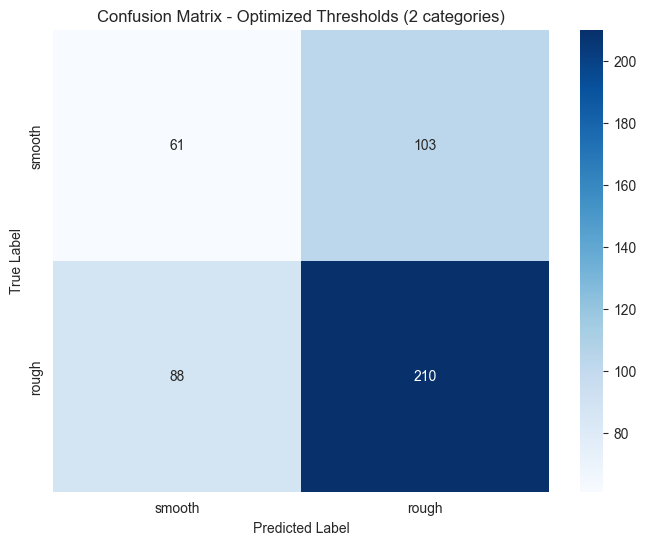

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       rough       0.67      0.70      0.69       298
      smooth       0.41      0.37      0.39       164

    accuracy                           0.59       462
   macro avg       0.54      0.54      0.54       462
weighted avg       0.58      0.59      0.58       462


=== PER-CLASS ACCURACY ===
smooth     accuracy: 37.20%
rough      accuracy: 70.47%
✓ Confusion matrix saved to calibration_results/confusion_matrix.png


In [24]:
# Cell 11: Validation - Confusion Matrix (binary smooth/rough)

def validate_thresholds(df_quality, thresholds):
    """Validate optimized thresholds and generate confusion matrix (smooth vs rough)."""
    # Coerce labels to binary
    df_binary = df_quality.copy()
    df_binary['manualLabel'] = df_binary['manualLabel'].replace({'average': 'rough'})

    def classify(row):
        if row['rms'] <= thresholds['rmsSmoothMax'] and row['peakCount'] <= thresholds['peakCountSmoothMax']:
            return 'smooth'
        else:
            return 'rough'

    predictions = df_binary.apply(classify, axis=1)

    cm = confusion_matrix(df_binary['manualLabel'], predictions, labels=['smooth', 'rough'])

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['smooth', 'rough'],
                yticklabels=['smooth', 'rough'])
    plt.title('Confusion Matrix - Optimized Thresholds (2 categories)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png', dpi=150)
    plt.show()

    print("=== CLASSIFICATION REPORT ===")
    print(classification_report(df_binary['manualLabel'], predictions))

    print("\n=== PER-CLASS ACCURACY ===")
    for label in ['smooth', 'rough']:
        mask = df_binary['manualLabel'] == label
        if mask.sum() > 0:
            accuracy = (predictions[mask] == label).mean()
            print(f"{label:10} accuracy: {accuracy:.2%}")

validate_thresholds(df_quality, grid_thresholds)
print(f"✓ Confusion matrix saved to {OUTPUT_DIR}/confusion_matrix.png")

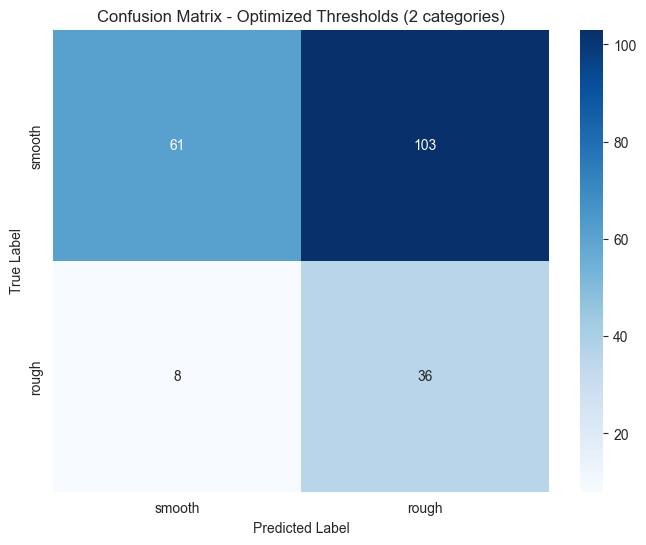

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     average       0.00      0.00      0.00       254
       rough       0.12      0.82      0.20        44
      smooth       0.41      0.37      0.39       164

    accuracy                           0.21       462
   macro avg       0.17      0.40      0.20       462
weighted avg       0.16      0.21      0.16       462


=== PER-CLASS ACCURACY ===
smooth     accuracy: 37.20%
rough      accuracy: 81.82%
✓ Confusion matrix saved to calibration_results/confusion_matrix.png


In [25]:
# Cell 11: Validation - Confusion Matrix
def validate_thresholds(df_quality, thresholds):
    """Validate optimized thresholds and generate confusion matrix."""
    def classify(row):
        if row['rms'] <= thresholds['rmsSmoothMax'] and row['peakCount'] <= thresholds['peakCountSmoothMax']:
            return 'smooth'
        else:
            return 'rough'
    
    predictions = df_quality.apply(classify, axis=1)
    
    # Confusion matrix
    cm = confusion_matrix(df_quality['manualLabel'], predictions, 
                          labels=['smooth', 'rough'])
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['smooth', 'rough'],
                yticklabels=['smooth', 'rough'])
    plt.title('Confusion Matrix - Optimized Thresholds (2 categories)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png', dpi=150)
    plt.show()
    
    # Classification report
    print("=== CLASSIFICATION REPORT ===")
    print(classification_report(df_quality['manualLabel'], predictions))
    
    # Accuracy by class
    print("\n=== PER-CLASS ACCURACY ===")
    for label in ['smooth', 'rough']:
        mask = df_quality['manualLabel'] == label
        if mask.sum() > 0:
            accuracy = (predictions[mask] == label).mean()
            print(f"{label:10} accuracy: {accuracy:.2%}")

validate_thresholds(df_quality, grid_thresholds)
print(f"✓ Confusion matrix saved to {OUTPUT_DIR}/confusion_matrix.png")

In [26]:
# Cell 12: Cross-Validation
def cross_validate_thresholds(df_quality, n_splits=5):
    """Perform k-fold cross-validation."""
    print(f"Running {n_splits}-fold cross-validation...\n")
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_scores = []
    
    for fold, (train_idx, test_idx) in enumerate(kf.split(df_quality)):
        train_df = df_quality.iloc[train_idx]
        test_df = df_quality.iloc[test_idx]
        
        # Optimize on train set (using percentile method for speed)
        train_thresholds = calculate_percentile_thresholds(train_df)
        
        # Evaluate on test set
        def classify(row):
            if row['rms'] <= train_thresholds['rmsSmoothMax'] and row['peakCount'] <= train_thresholds['peakCountSmoothMax']:
                return 'smooth'
            else:
                return 'rough'
        
        predictions = test_df.apply(classify, axis=1)
        f1 = f1_score(test_df['manualLabel'], predictions, average='binary', pos_label='smooth')
        fold_scores.append(f1)
        print(f"Fold {fold + 1} F1 Score: {f1:.4f}")
    
    print(f"\n=== CROSS-VALIDATION RESULTS ===")
    print(f"Mean F1 Score: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")
    
    return fold_scores

cv_scores = cross_validate_thresholds(df_quality)

Running 5-fold cross-validation...



ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].

In [ ]:
# Cell 13: Generate Final Recommendations
# Combine all methods
final_recommendations = {
    'rmsSmoothMax': grid_thresholds['rmsSmoothMax'],
    'peakThresholdZ': DEFAULT_THRESHOLDS['peakThresholdZ'],  # Keep default
    'symmetricBumpThreshold': feature_thresholds.get('symmetricBumpThreshold', DEFAULT_THRESHOLDS['symmetricBumpThreshold']),
    'potholeDipThreshold': feature_thresholds.get('potholeDipThreshold', DEFAULT_THRESHOLDS['potholeDipThreshold']),
    'bumpSpikeThreshold': feature_thresholds.get('bumpSpikeThreshold', DEFAULT_THRESHOLDS['bumpSpikeThreshold']),
    'peakCountSmoothMax': grid_thresholds['peakCountSmoothMax'],
    'movingAverageWindow': DEFAULT_THRESHOLDS['movingAverageWindow']  # Keep default
}

print("=== FINAL RECOMMENDED THRESHOLDS ===\n")
print(f"{'Parameter':<28} | {'Optimized':>9} | {'Default':>8} | {'Change':>7}")
print("-" * 65)
for key in DEFAULT_THRESHOLDS.keys():
    optimized = final_recommendations[key]
    default = DEFAULT_THRESHOLDS[key]
    change = ((optimized - default) / default * 100) if default != 0 else 0
    print(f"{key:<28} | {optimized:9.3f} | {default:8.3f} | {change:+6.1f}%")

✓ Profile exported to: calibration_results/Optimized_Motorcycle.profile.json

✓ You can now load this profile in your app!


In [ ]:
# Cell 14: Export Optimized Profile
def export_profile(thresholds, profile_name="Optimized"):
    """Export thresholds as vehicle profile JSON."""
    import time
    
    profile = {
        "name": profile_name,
        "calibration": {
            "rmsSmoothMax": float(thresholds['rmsSmoothMax']),
            "peakThresholdZ": float(thresholds['peakThresholdZ']),
            "symmetricBumpThreshold": float(thresholds['symmetricBumpThreshold']),
            "potholeDipThreshold": float(thresholds['potholeDipThreshold']),
            "bumpSpikeThreshold": float(thresholds['bumpSpikeThreshold']),
            "peakCountSmoothMax": int(thresholds['peakCountSmoothMax']),
            "movingAverageWindow": int(thresholds['movingAverageWindow'])
        },
        "createdAt": int(time.time() * 1000),
        "lastModified": int(time.time() * 1000)
    }
    
    filename = f"{OUTPUT_DIR}/{profile_name}.profile.json"
    with open(filename, 'w') as f:
        json.dump(profile, f, indent=2)
    
    print(f"Profile exported to: {filename}")
    return filename

# Export optimized profile
profile_file = export_profile(final_recommendations, "Optimized_Motorcycle")
print(f"\nYou can now load this profile in your app!")


CALIBRATION ANALYSIS SUMMARY

Dataset: track_20260202_162252.json
Total Samples: 462
Samples with Quality Labels: 462
Samples with Feature Labels: 7

OPTIMIZED THRESHOLDS:
  rmsSmoothMax:             0.833
  rmsAverageMax:            1.500
  peakCountSmoothMax:       7
  peakCountAverageMax:      19
  symmetricBumpThreshold:   19.145
  potholeDipThreshold:      -2.500
  bumpSpikeThreshold:       29.260

PERFORMANCE METRICS:
  Grid Search F1 Score:     0.0533
  Cross-Validation F1:      0.1861 ± 0.0458

OUTPUT FILES:
  Optimized Profile:        calibration_results/Optimized_Motorcycle.profile.json
  Visualizations:           calibration_results/
    - eda_road_quality.png
    - eda_features.png
    - decision_tree.png
    - confusion_matrix.png

Analysis complete! ✓



UnicodeEncodeError: 'charmap' codec can't encode character '\u2713' in position 1236: character maps to <undefined>

In [27]:
# Cell 15: Summary Report
# Generate summary report
report = f"""
{'='*70}
CALIBRATION ANALYSIS SUMMARY
{'='*70}

Dataset: {TRACK_FILE}
Total Samples: {len(df)}
Samples with Quality Labels: {len(df_quality)}
Samples with Feature Labels: {len(df_features)}
Road Quality Categories: 2 (smooth, rough)

OPTIMIZED THRESHOLDS:
{'='*70}
  rmsSmoothMax:             {final_recommendations['rmsSmoothMax']:.3f}
  peakCountSmoothMax:       {final_recommendations['peakCountSmoothMax']}
  symmetricBumpThreshold:   {final_recommendations['symmetricBumpThreshold']:.3f}
  potholeDipThreshold:      {final_recommendations['potholeDipThreshold']:.3f}
  bumpSpikeThreshold:       {final_recommendations['bumpSpikeThreshold']:.3f}

PERFORMANCE METRICS:
{'='*70}
  Grid Search F1 Score:     {grid_f1:.4f}
  Cross-Validation F1:      {np.mean(cv_scores):.4f} +/- {np.std(cv_scores):.4f}

OUTPUT FILES:
{'='*70}
  Optimized Profile:        {profile_file}
  Visualizations:           {OUTPUT_DIR}/
    - eda_road_quality.png
    - eda_features.png
    - decision_tree.png
    - confusion_matrix.png

{'='*70}
Analysis complete!
{'='*70}
"""

print(report)

# Save report (using utf-8 encoding to avoid Unicode errors)
with open(f'{OUTPUT_DIR}/analysis_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)

print(f"\nReport saved to {OUTPUT_DIR}/analysis_report.txt")

NameError: name 'final_recommendations' is not defined